In [1]:
import pandas as pd

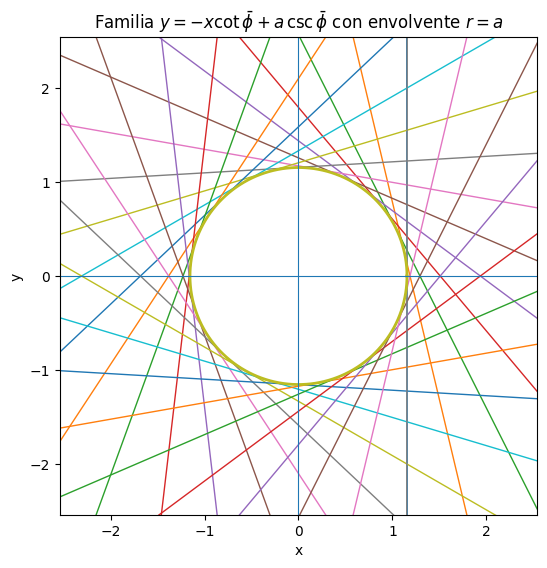

In [3]:
# --- Parámetros y librerías ---
import numpy as np
import matplotlib.pyplot as plt

def plot_rectas_kepler(l, m, E, n_phi=24, x_factor=2.2, savepath=None):
    """
    Dibuja la familia de rectas x cosφ + y sinφ = a, con a = l / sqrt(2 m E),
    y el círculo envolvente x^2 + y^2 = a^2 en el plano xy.

    Args:
        l, m, E : flotantes físicos (mismas unidades consistentes)
        n_phi   : número de muestras de φ en [0, 2π]
        x_factor: multiplica a para fijar límites de los ejes
        savepath: ruta (str) para guardar el PNG; si None, no guarda
    """
    # a = l / sqrt(2 m E)
    a = l / np.sqrt(2.0 * m * E)

    # Muestreamos φ evitando sinφ ~ 0 (singularidades en 0, π, 2π)
    eps = 1e-3
    phis = np.linspace(0.0 + eps, 2*np.pi - eps, n_phi)

    # Rango de x centrado en 0 y acorde a 'a'
    XMAX = x_factor * a
    x = np.linspace(-XMAX, XMAX, 600)

    # Figura
    plt.figure(figsize=(6.2, 6.2))

    # Familia de rectas: y = -x cotφ + a cscφ
    # (equivalente a x cosφ + y sinφ = a)
    for phi in phis:
        s = np.sin(phi)
        c = np.cos(phi)
        # Evitar divisiones numéricas peligrosas si |sinφ| es muy chica
        if abs(s) < 1e-6:
            continue
        y = -x * (c / s) + a * (1.0 / s)
        plt.plot(x, y, linewidth=1)

    # Envolvente: círculo r = a
    th = np.linspace(0, 2*np.pi, 600)
    xc = a * np.cos(th)
    yc = a * np.sin(th)
    plt.plot(xc, yc, linewidth=2)

    # Ejes y aspecto
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-XMAX, XMAX)
    plt.ylim(-XMAX, XMAX)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(r"Familia $y=-x\cot\bar{\phi}+a\,\csc\bar{\phi}$ con envolvente $r=a$")

    if savepath is not None:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

# ==== EJEMPLO DE USO ====
# Elige valores físicos (unidades consistentes). Por ejemplo:
l = 2.0   # momento angular
m = 1.0   # masa
E = 1.5   # energía
plot_rectas_kepler(l, m, E, n_phi=28, savepath="rectas_kepler.png")


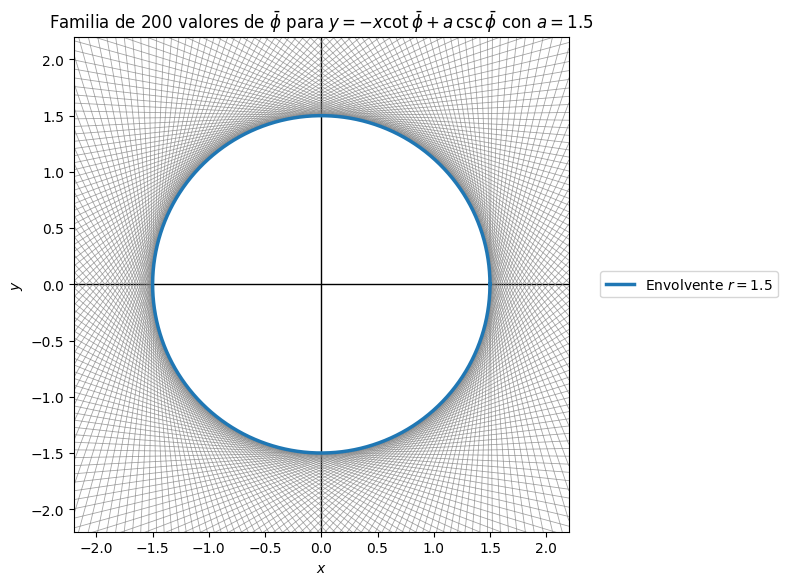

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetro fijo
a = 1.5
phi_vals = np.linspace(0.01, 2 * np.pi - 0.01, 200)  # Evita 0 y 2pi para no dividir por cero
x_vals = np.linspace(-2.2, 2.2, 400)

# Preparar figura
plt.figure(figsize=(8, 8))
ax = plt.gca()
ax.set_aspect('equal')
plt.title(r'Familia de 200 valores de $\bar{\phi}$ para $y = -x\cot\bar{\phi} + a\,\csc\bar{\phi}$ con $a = 1.5$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.xlim(-2.2, 2.2)
plt.ylim(-2.2, 2.2)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Dibujar las 200 rectas
for phi in phi_vals:
    y_vals = -x_vals / np.tan(phi) + a / np.sin(phi)
    plt.plot(x_vals, y_vals, color='gray', linewidth=0.6, alpha=0.7)

# Dibujar el círculo envolvente
theta = np.linspace(0, 2 * np.pi, 500)
circle_x = a * np.cos(theta)
circle_y = a * np.sin(theta)
plt.plot(circle_x, circle_y, color='tab:blue', linewidth=2.5, label=rf'Envolvente $r = {a}$')

plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.grid(False)
plt.tight_layout()
plt.show()


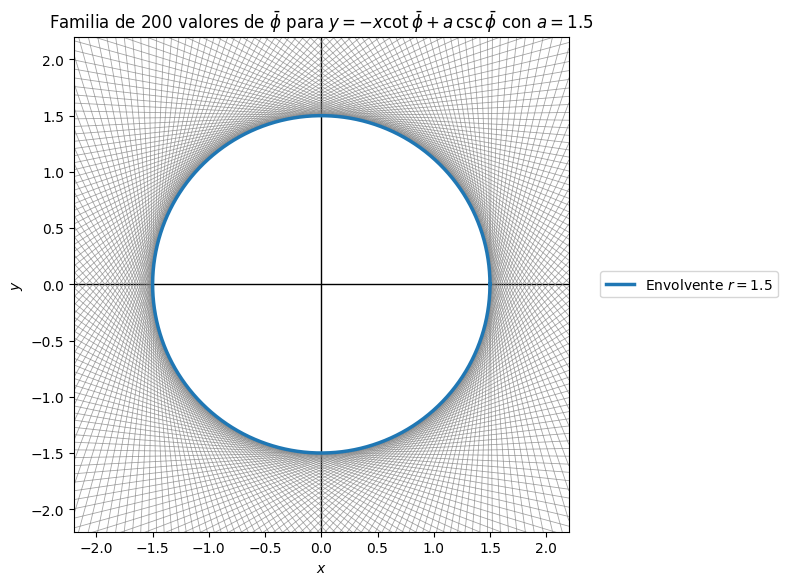

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetro fijo
a = 1.5
phi_vals = np.linspace(0.01, 2 * np.pi - 0.01, 200)  # Evita 0 y 2pi para no dividir por cero
x_vals = np.linspace(-2.2, 2.2, 400)

# Preparar figura
plt.figure(figsize=(8, 8))
ax = plt.gca()
ax.set_aspect('equal')
plt.title(r'Familia de 200 valores de $\bar{\phi}$ para $y = -x\cot\bar{\phi} + a\,\csc\bar{\phi}$ con $a = 1.5$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.xlim(-2.2, 2.2)
plt.ylim(-2.2, 2.2)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Dibujar las 200 rectas
for phi in phi_vals:
    y_vals = -x_vals / np.tan(phi) + a / np.sin(phi)
    plt.plot(x_vals, y_vals, color='gray', linewidth=0.6, alpha=0.7)

# Dibujar el círculo envolvente
theta = np.linspace(0, 2 * np.pi, 500)
circle_x = a * np.cos(theta)
circle_y = a * np.sin(theta)
plt.plot(circle_x, circle_y, color='tab:blue', linewidth=2.5, label=rf'Envolvente $r = {a}$')

plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.grid(False)
plt.tight_layout()

# GUARDAR como PNG (añade esta línea)
plt.savefig("familia_rectas_200valores.png", dpi=300)

# Mostrar en pantalla
plt.show()


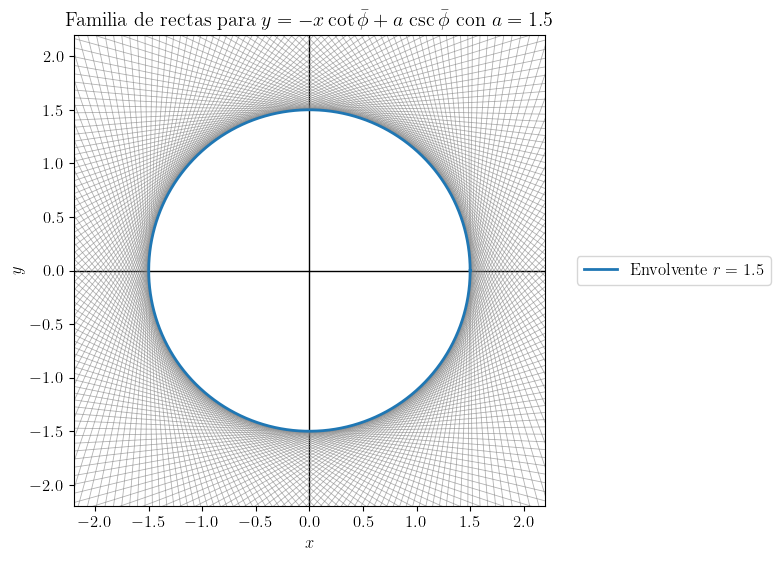

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Estilo general más limpio y profesional
plt.style.use("default")  # limpio y profesional
# o si quieres otro más sobrio:
# plt.style.use("classic")
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12
})

def plot_familia_rectas(a=1.5, N=200, xlim=(-2.2, 2.2), ylim=(-2.2, 2.2),
                        filename="familia_rectas.png"):
    """
    Grafica una familia de N rectas definidas por
    y = -x cot(phi) + a csc(phi)
    y su envolvente circular de radio a.
    """

    phi_vals = np.linspace(0.01, 2*np.pi - 0.01, N)  # evita división por cero
    x_vals = np.linspace(*xlim, 400)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect("equal")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Ejes
    ax.axhline(0, color="black", lw=1)
    ax.axvline(0, color="black", lw=1)

    # Rectas individuales
    for phi in phi_vals:
        y_vals = -x_vals / np.tan(phi) + a / np.sin(phi)
        ax.plot(x_vals, y_vals, color='gray', lw=0.6, alpha=0.6)

    # Envolvente: círculo de radio a
    theta = np.linspace(0, 2*np.pi, 500)
    ax.plot(a*np.cos(theta), a*np.sin(theta),
            color="tab:blue", lw=2, label=rf"Envolvente $r = {a}$")

    # Etiquetas
    ax.set_title(rf"Familia de rectas para $y = -x\cot\bar{{\phi}} + a\,\csc\bar{{\phi}}$ con $a={a}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))
    plt.tight_layout()

    # Guardar en PNG y PDF
    fig.savefig(filename, dpi=300)
    fig.savefig(filename.replace(".png", ".pdf"))
    plt.show()

# Ejecutar
plot_familia_rectas()


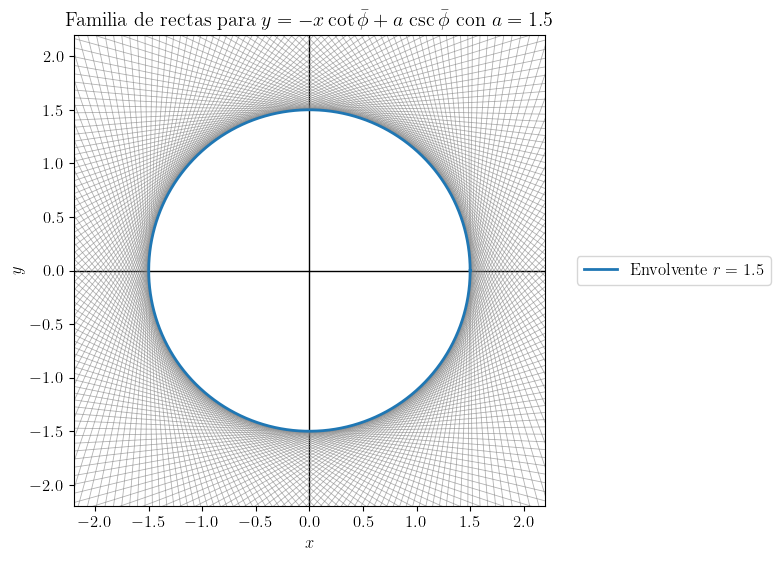

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Estilo general limpio y profesional
plt.style.use("default")
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12
})

def plot_familia_rectas(a=1.5, N=200, xlim=(-2.2, 2.2), ylim=(-2.2, 2.2),
                        filename="familia_rectas.png"):
    """
    Grafica una familia de N rectas definidas por
    y = -x cot(phi) + a csc(phi)
    y su envolvente circular de radio a.
    """

    phi_vals = np.linspace(0.01, 2*np.pi - 0.01, N)  # evita división por cero
    x_vals = np.linspace(*xlim, 400)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect("equal")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Ejes
    ax.axhline(0, color="black", lw=1)
    ax.axvline(0, color="black", lw=1)

    # Rectas individuales
    for phi in phi_vals:
        y_vals = -x_vals / np.tan(phi) + a / np.sin(phi)
        ax.plot(x_vals, y_vals, color='gray', lw=0.6, alpha=0.6)

    # Envolvente: círculo de radio a
    theta = np.linspace(0, 2*np.pi, 500)
    ax.plot(a*np.cos(theta), a*np.sin(theta),
            color="tab:blue", lw=2, label=rf"Envolvente $r = {a}$")

    # Etiquetas
    ax.set_title(rf"Familia de rectas para $y = -x\cot\bar{{\phi}} + a\,\csc\bar{{\phi}}$ con $a={a}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))
    plt.tight_layout()

    # Guardar con fondo transparente
    fig.savefig(filename, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(filename.replace(".png", ".pdf"), bbox_inches='tight', transparent=True)

    plt.show()

# Ejecutar
plot_familia_rectas()


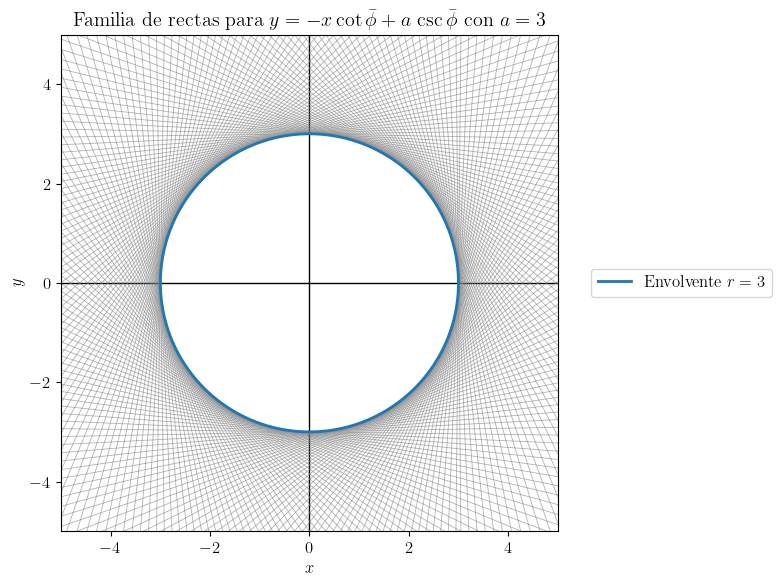

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Estilo general limpio y profesional
plt.style.use("default")
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12
})

def plot_familia_rectas(a=3, N=200, xlim=(-5, 5), ylim=(-5, 5),
                        filename="familia_rectas.png"):
    """
    Grafica una familia de N rectas definidas por
    y = -x cot(phi) + a csc(phi)
    y su envolvente circular de radio a.
    """

    phi_vals = np.linspace(0.01, 2*np.pi - 0.01, N)  # evita división por cero
    x_vals = np.linspace(*xlim, 400)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect("equal")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Ejes
    ax.axhline(0, color="black", lw=1)
    ax.axvline(0, color="black", lw=1)

    # Rectas individuales
    for phi in phi_vals:
        y_vals = -x_vals / np.tan(phi) + a / np.sin(phi)
        ax.plot(x_vals, y_vals, color='gray', lw=0.6, alpha=0.6)

    # Envolvente: círculo de radio a
    theta = np.linspace(0, 2*np.pi, 500)
    ax.plot(a*np.cos(theta), a*np.sin(theta),
            color="tab:blue", lw=2, label=rf"Envolvente $r = {a}$")

    # Etiquetas
    ax.set_title(rf"Familia de rectas para $y = -x\cot\bar{{\phi}} + a\,\csc\bar{{\phi}}$ con $a={a}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))
    plt.tight_layout()

    # Guardar con fondo transparente
    fig.savefig(filename, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(filename.replace(".png", ".pdf"), bbox_inches='tight', transparent=True)

    plt.show()

# Ejecutar
plot_familia_rectas()